## Figure 7: Neurite signal enrichment analysis ##

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

## Step 1: Compile background signal measurements per channel ##

For each channel, background measurements are MGV averaged over ROIs traced within images, and are saved as "BG_" .csv files. BG for EML4, MAP2, and MAP7D1 are analyzed separately, in separate analysis folders to prevent file convolution.

In [13]:
import pandas as pd
from pathlib import Path
from tkinter import filedialog
import re

# --------------------------------------------------------
# Select folder containing all CSV files
# --------------------------------------------------------

print("Select folder containing all ROI measurement CSVs")

folder = filedialog.askdirectory(
    title="Select folder containing ROI CSV files"
)

DATA_DIR = Path(folder)

print(f"\nSelected folder:\n{DATA_DIR}\n")

# --------------------------------------------------------
# Parse filenames
# --------------------------------------------------------

def parse_filename(path):

    stem = path.stem

    pattern = (
        r"^(?P<roi_type>BG|GC|Soma)_"
        r"(?P<div>DIV\d+)_"
        r"(?P<fov>FOV\d+)_"
        r"(?P<species>TUBB3|MAP7D1|DCX)$"
    )

    match = re.match(pattern, stem)

    if match is None:
        print(f"Skipping unrecognized filename: {path.name}")
        return None

    return match.groupdict()

# --------------------------------------------------------
# Read all BG files
# --------------------------------------------------------

bg_records = []

bg_files = sorted(DATA_DIR.glob("BG_*.csv"))

print(f"Found {len(bg_files)} background files.\n")

for file in bg_files:

    info = parse_filename(file)

    if info is None:
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Mean" not in df.columns:
        print(f"Skipping {file.name}: no 'Mean' column found")
        continue

    bg_records.append({
        "DIV": info["div"],
        "FOV": info["fov"],
        "species": info["species"],
        "bg_mean": df["Mean"].mean(),
        "bg_sd": df["Mean"].std(),
        "n_bg_rois": len(df),
        "source_file": file.name
    })

bg_values = pd.DataFrame(bg_records)

bg_values = (
    bg_values
    .sort_values(["DIV", "FOV", "species"])
    .reset_index(drop=True)
)

print("Background summary:")
display(bg_values)

Select folder containing all ROI measurement CSVs

Selected folder:
D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis

Found 36 background files.

Background summary:


,DIV,FOV,species,bg_mean,bg_sd,n_bg_rois,source_file
0,DIV2,FOV1,DCX,112.135133,1.780293,15,BG_DIV2_FOV1_DCX.csv
1,DIV2,FOV1,MAP7D1,186.131400,16.941215,15,BG_DIV2_FOV1_MAP7D1.csv
2,DIV2,FOV1,TUBB3,127.731267,5.936950,15,BG_DIV2_FOV1_TUBB3.csv
3,DIV2,FOV2,DCX,113.287111,1.895146,9,BG_DIV2_FOV2_DCX.csv
4,DIV2,FOV2,MAP7D1,175.182556,37.822513,9,BG_DIV2_FOV2_MAP7D1.csv
5,DIV2,FOV2,TUBB3,123.266667,3.266076,9,BG_DIV2_FOV2_TUBB3.csv
6,DIV2,FOV3,DCX,88.647833,1.217398,12,BG_DIV2_FOV3_DCX.csv
7,DIV2,FOV3,MAP7D1,130.759750,6.229626,12,BG_DIV2_FOV3_MAP7D1.csv
8,DIV2,FOV3,TUBB3,99.604167,1.952832,12,BG_DIV2_FOV3_TUBB3.csv
9,DIV3,FOV1,DCX,101.650133,1.756344,15,BG_DIV3_FOV1_DCX.csv


## Step 2: Compile Max signal measurements per channel ##

Max signal is averaged over ROIs of Soma, where signal is enriched in each channel. Files used for normalization of max signal are "Soma_" .csv files.

In [14]:
# --------------------------------------------------------
# Read all Soma files
# --------------------------------------------------------

soma_records = []

soma_files = sorted(DATA_DIR.glob("Soma_*.csv"))

print(f"Found {len(soma_files)} soma files.\n")

for file in soma_files:

    info = parse_filename(file)

    if info is None:
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Max" not in df.columns:
        print(f"Skipping {file.name}: no 'Max' column found")
        continue

    soma_records.append({
        "DIV": info["div"],
        "FOV": info["fov"],
        "species": info["species"],
        "positive_max": df["Max"].mean(),
        "positive_sd": df["Max"].std(),
        "n_soma_rois": len(df),
        "source_file": file.name
    })

soma_values = pd.DataFrame(soma_records)

soma_values = (
    soma_values
    .sort_values(["DIV", "FOV", "species"])
    .reset_index(drop=True)
)

print("Positive control summary:")
display(soma_values)

Found 36 soma files.

Positive control summary:


,DIV,FOV,species,positive_max,positive_sd,n_soma_rois,source_file
0,DIV2,FOV1,DCX,599.454545,98.993296,11,Soma_DIV2_FOV1_DCX.csv
1,DIV2,FOV1,MAP7D1,5801.454545,1664.045334,11,Soma_DIV2_FOV1_MAP7D1.csv
2,DIV2,FOV1,TUBB3,1438.000000,304.538011,11,Soma_DIV2_FOV1_TUBB3.csv
3,DIV2,FOV2,DCX,734.400000,109.591514,5,Soma_DIV2_FOV2_DCX.csv
4,DIV2,FOV2,MAP7D1,4568.800000,1318.906062,5,Soma_DIV2_FOV2_MAP7D1.csv
5,DIV2,FOV2,TUBB3,1743.400000,285.646285,5,Soma_DIV2_FOV2_TUBB3.csv
6,DIV2,FOV3,DCX,695.500000,153.513843,10,Soma_DIV2_FOV3_DCX.csv
7,DIV2,FOV3,MAP7D1,5725.300000,1720.615914,10,Soma_DIV2_FOV3_MAP7D1.csv
8,DIV2,FOV3,TUBB3,1434.100000,389.656387,10,Soma_DIV2_FOV3_TUBB3.csv
9,DIV3,FOV1,DCX,989.636364,250.097690,11,Soma_DIV3_FOV1_DCX.csv


## Step 3: Compile neurite intensity profiles (lw=3) ##

Neurite profiles are exported from FIJI (ImageJ) as .csv files labeled as "Line_".

In [15]:
import numpy as np
import pandas as pd
import re
from scipy.signal import savgol_filter

# --------------------------------------------------------
# Load all Line_ files automatically
# ImageJ format:
# Distance_(microns), Value, X1, Y1, X2, Y2...
# Intensities are: Value, Y1, Y2, Y3...
# --------------------------------------------------------

line_records = []

line_files = sorted(DATA_DIR.glob("Line_*.csv"))

print(f"Found {len(line_files)} Line files.\n")

for file in line_files:

    parts = file.stem.split("_")

    if len(parts) != 4:
        print(f"Skipping {file.name}: unrecognized filename")
        continue

    roi_type, div, fov, species = parts

    if roi_type != "Line":
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Distance_(microns)" not in df.columns:
        print(f"Skipping {file.name}: no Distance_(microns) column")
        continue

    distance_col = "Distance_(microns)"

    intensity_cols = ["Value"] + [
        col for col in df.columns
        if re.match(r"^Y\d+$", col)
    ]

    print(f"{file.name}: found {len(intensity_cols)} ROI profiles")

    for roi_num, intensity_col in enumerate(intensity_cols, start=1):

        for i, row in df.iterrows():

            line_records.append({
                "DIV": div,
                "FOV": fov,
                "species": species,
                "channel": species,
                "roi_id": f"ROI_{roi_num}",
                "distance_um": row[distance_col],
                "intensity_raw": row[intensity_col],
                "source_file": file.name,
                "source_column": intensity_col
            })

lineplots_auto = pd.DataFrame(line_records)

print("Loaded line profiles:")
display(lineplots_auto.head())

print("\nROI counts per DIV/FOV/species:")
display(
    lineplots_auto
    .groupby(["DIV", "FOV", "species"])["roi_id"]
    .nunique()
    .reset_index(name="n_rois")
)


# --------------------------------------------------------
# Make BG and Soma lookup tables
# --------------------------------------------------------

bg_lookup = (
    bg_values
    .set_index(["DIV", "FOV", "species"])["bg_mean"]
    .to_dict()
)

soma_lookup = (
    soma_values
    .set_index(["DIV", "FOV", "species"])["positive_max"]
    .to_dict()
)


# --------------------------------------------------------
# Helper functions
# --------------------------------------------------------

def minmax_norm(y):
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    y = y.replace([np.inf, -np.inf], np.nan)
    y = y.interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(y) == 0 or np.all(np.isnan(y)):
        return y

    if np.nanmax(y) == np.nanmin(y):
        return np.zeros_like(y)

    return (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))


def safe_smooth(y, window=9, poly=2):
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    y = y.replace([np.inf, -np.inf], np.nan)
    y = y.interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(y) < 5:
        return y

    if np.all(np.isnan(y)):
        return y

    if window % 2 == 0:
        window += 1

    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if window <= poly:
        return y

    try:
        return savgol_filter(
            y,
            window_length=window,
            polyorder=poly,
            mode="nearest"
        )
    except Exception as e:
        print(f"Smoothing skipped: {e}")
        return y


# --------------------------------------------------------
# Process line profiles
# --------------------------------------------------------

processed_records = []

for (div, fov, species, roi_id), g in lineplots_auto.groupby(
    ["DIV", "FOV", "species", "roi_id"]
):

    key = (div, fov, species)

    if key not in bg_lookup:
        print(f"Skipping {div} {fov} {species} {roi_id}: no matching BG")
        continue

    if key not in soma_lookup:
        print(f"Skipping {div} {fov} {species} {roi_id}: no matching Soma")
        continue

    g = g.copy()

    g["distance_um"] = pd.to_numeric(g["distance_um"], errors="coerce")
    g["intensity_raw"] = pd.to_numeric(g["intensity_raw"], errors="coerce")

    g = g.dropna(subset=["distance_um", "intensity_raw"])
    g = g.sort_values("distance_um")

    if len(g) < 2:
        print(f"Skipping {div} {fov} {species} {roi_id}: not enough points")
        continue

    x = g["distance_um"].to_numpy(dtype=float)
    y = g["intensity_raw"].to_numpy(dtype=float)

    if np.nanmax(x) == np.nanmin(x):
        print(f"Skipping {div} {fov} {species} {roi_id}: distance range is zero")
        continue

    bg = bg_lookup[key]
    soma_max = soma_lookup[key]
    denom = soma_max - bg

    distance_norm = (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

    intensity_bgsub = y - bg

    if denom == 0:
        intensity_norm_soma_max = np.full_like(y, np.nan, dtype=float)
    else:
        intensity_norm_soma_max = (y - bg) / denom

    intensity_bgsub_smooth = safe_smooth(intensity_bgsub)
    intensity_norm_soma_max_smooth = safe_smooth(intensity_norm_soma_max)
    intensity_profile_minmax = minmax_norm(intensity_bgsub_smooth)

    for i in range(len(x)):

        processed_records.append({
            "DIV": div,
            "FOV": fov,
            "species": species,
            "channel": species,
            "roi_id": roi_id,
            "source_file": g["source_file"].iloc[0],
            "source_column": g["source_column"].iloc[0],

            "distance_um": x[i],
            "distance_norm": distance_norm[i],

            "intensity_raw": y[i],
            "background_value": bg,
            "soma_max_value": soma_max,

            "intensity_bgsub": intensity_bgsub[i],
            "intensity_bgsub_smooth": intensity_bgsub_smooth[i],

            "intensity_norm_soma_max": intensity_norm_soma_max[i],
            "intensity_norm_soma_max_smooth": intensity_norm_soma_max_smooth[i],

            "intensity_profile_minmax": intensity_profile_minmax[i]
        })

processed_df = pd.DataFrame(processed_records)

processed_df = (
    processed_df
    .sort_values(["DIV", "FOV", "roi_id", "species", "distance_um"])
    .reset_index(drop=True)
)

display(processed_df.head())

print("\nProcessed ROI counts per DIV/FOV:")
display(
    processed_df
    .groupby(["DIV", "FOV"])["roi_id"]
    .nunique()
    .reset_index(name="n_rois")
)

Found 21 Line files.

Line_DIV3_FOV2_DCX.csv: found 12 ROI profiles
Line_DIV3_FOV2_MAP7D1.csv: found 12 ROI profiles
Line_DIV3_FOV2_TUBB3.csv: found 12 ROI profiles
Line_DIV3_FOV3_DCX.csv: found 27 ROI profiles
Line_DIV3_FOV3_MAP7D1.csv: found 27 ROI profiles
Line_DIV3_FOV3_TUBB3.csv: found 27 ROI profiles
Line_DIV4_FOV1_DCX.csv: found 18 ROI profiles
Line_DIV4_FOV1_MAP7D1.csv: found 18 ROI profiles
Line_DIV4_FOV1_TUBB3.csv: found 18 ROI profiles
Line_DIV4_FOV2_DCX.csv: found 30 ROI profiles
Line_DIV4_FOV2_MAP7D1.csv: found 30 ROI profiles
Line_DIV4_FOV2_TUBB3.csv: found 30 ROI profiles
Line_DIV4_FOV3_DCX.csv: found 22 ROI profiles
Line_DIV4_FOV3_MAP7D1.csv: found 22 ROI profiles
Line_DIV4_FOV3_TUBB3.csv: found 22 ROI profiles
Line_DIV5_FOV1_MAP7D1.csv: found 18 ROI profiles
Line_DIV5_FOV1_TUBB3.csv: found 18 ROI profiles
Line_DIV5_FOV2_MAP7D1.csv: found 22 ROI profiles
Line_DIV5_FOV2_TUBB3.csv: found 22 ROI profiles
Line_DIV5_FOV3_MAP7D1.csv: found 15 ROI profiles
Line_DIV5_FOV3_TUBB3

,DIV,FOV,species,channel,roi_id,distance_um,intensity_raw,source_file,source_column
0,DIV3,FOV2,DCX,DCX,ROI_1,0.000,388.000,Line_DIV3_FOV2_DCX.csv,Value
1,DIV3,FOV2,DCX,DCX,ROI_1,0.227,357.177,Line_DIV3_FOV2_DCX.csv,Value
2,DIV3,FOV2,DCX,DCX,ROI_1,0.454,373.169,Line_DIV3_FOV2_DCX.csv,Value
3,DIV3,FOV2,DCX,DCX,ROI_1,0.681,387.784,Line_DIV3_FOV2_DCX.csv,Value
4,DIV3,FOV2,DCX,DCX,ROI_1,0.908,377.607,Line_DIV3_FOV2_DCX.csv,Value



ROI counts per DIV/FOV/species:


,DIV,FOV,species,n_rois
0,DIV3,FOV2,DCX,12
1,DIV3,FOV2,MAP7D1,12
2,DIV3,FOV2,TUBB3,12
3,DIV3,FOV3,DCX,27
4,DIV3,FOV3,MAP7D1,27
5,DIV3,FOV3,TUBB3,27
6,DIV4,FOV1,DCX,18
7,DIV4,FOV1,MAP7D1,18
8,DIV4,FOV1,TUBB3,18
9,DIV4,FOV2,DCX,30


,DIV,FOV,species,channel,roi_id,source_file,source_column,distance_um,distance_norm,intensity_raw,background_value,soma_max_value,intensity_bgsub,intensity_bgsub_smooth,intensity_norm_soma_max,intensity_norm_soma_max_smooth,intensity_profile_minmax
0,DIV3,FOV2,DCX,DCX,ROI_1,Line_DIV3_FOV2_DCX.csv,Value,0.000,0.000000,388.000,102.064733,918.909091,285.935267,277.157682,0.350049,0.339303,0.674670
1,DIV3,FOV2,DCX,DCX,ROI_1,Line_DIV3_FOV2_DCX.csv,Value,0.227,0.004854,357.177,102.064733,918.909091,255.112267,273.346574,0.312314,0.334637,0.664033
2,DIV3,FOV2,DCX,DCX,ROI_1,Line_DIV3_FOV2_DCX.csv,Value,0.454,0.009709,373.169,102.064733,918.909091,271.104267,270.958730,0.331892,0.331714,0.657369
3,DIV3,FOV2,DCX,DCX,ROI_1,Line_DIV3_FOV2_DCX.csv,Value,0.681,0.014563,387.784,102.064733,918.909091,285.719267,272.555829,0.349784,0.333669,0.661826
4,DIV3,FOV2,DCX,DCX,ROI_1,Line_DIV3_FOV2_DCX.csv,Value,0.908,0.019417,377.607,102.064733,918.909091,275.542267,282.177708,0.337325,0.345449,0.688681



Processed ROI counts per DIV/FOV:


,DIV,FOV,n_rois
0,DIV3,FOV2,12
1,DIV3,FOV3,27
2,DIV4,FOV1,18
3,DIV4,FOV2,30
4,DIV4,FOV3,22
5,DIV5,FOV1,18
6,DIV5,FOV2,22
7,DIV5,FOV3,15


## Plot profiles corrected for channel-specific BG and MAX signal ##

Script normalizes neurite profile x values according to background signal and average maximum signal. Neurites are also normalized to length = 1.0.

In [16]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --------------------------------------------------------
# Output folder
# --------------------------------------------------------

LINE_OUT_DIR = DATA_DIR / "Processed_LineProfiles"
LINE_OUT_DIR.mkdir(exist_ok=True)

processed_df.to_csv(
    LINE_OUT_DIR / "all_processed_lineprofiles.csv",
    index=False
)

print(f"Saved processed_df to:\n{LINE_OUT_DIR / 'all_processed_lineprofiles.csv'}")

# --------------------------------------------------------
# Colors
# --------------------------------------------------------

colors = {
    "TUBB3": "#00BCD4",
    "DCX": "#555555",
    # "EML4": "#F48FB1"
    "MAP7D1": "#C2185B",
    # "MAP2": "#C2185B"
}

# --------------------------------------------------------
# ROI sorting helper
# --------------------------------------------------------

def natural_sort_key(x):
    return [
        int(text) if text.isdigit() else text.lower()
        for text in re.split(r"(\d+)", str(x))
    ]

# --------------------------------------------------------
# Plot first N line-profile ROIs from selected DIV/FOV
# --------------------------------------------------------

def plot_lineprofiles_by_div_fov(
    processed_df,
    div,
    fov,
    n_rois=5,
    y_col="intensity_norm_soma_max_smooth",
    x_col="distance_norm",
    save=True
):

    subset = processed_df[
        (processed_df["DIV"] == div) &
        (processed_df["FOV"] == fov)
    ].copy()

    if subset.empty:
        print(f"No data found for {div} {fov}")
        return

    roi_ids = sorted(
        subset["roi_id"].dropna().unique(),
        key=natural_sort_key
    )[:n_rois]

    print(f"Plotting first {len(roi_ids)} ROI(s) for {div} {fov}:")
    print(roi_ids)

    for roi_id in roi_ids:

        g_roi = subset[subset["roi_id"] == roi_id].copy()

        plt.figure(figsize=(5, 4))

        for species in ["TUBB3","MAP7D1","DCX"]:

            g = g_roi[g_roi["species"] == species].copy()

            if g.empty:
                continue

            g = g.sort_values(x_col)

            plt.plot(
                g[x_col],
                g[y_col],
                linewidth=2,
                color=colors[species],
                label=species
            )

        plt.title(f"{div} {fov} • {roi_id}")
        plt.xlabel("Normalized distance")
        plt.ylabel("Normalized intensity")
        plt.xlim(0, 1)
        plt.ylim(0,0.8)
        plt.legend(frameon=False)
        plt.tight_layout()

        if save:
            filename = f"{div}_{fov}_{roi_id}_{y_col}.png"
            save_path = LINE_OUT_DIR / filename
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")
            
            filename = f"{div}_{fov}_{roi_id}_{y_col}.svg"
            save_path = LINE_OUT_DIR / filename
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")

        plt.show()

Saved processed_df to:
D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\all_processed_lineprofiles.csv


Plotting first 3 ROI(s) for DIV4 FOV3:
['ROI_1', 'ROI_2', 'ROI_3']
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\DIV4_FOV3_ROI_1_intensity_norm_soma_max_smooth.png
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\DIV4_FOV3_ROI_1_intensity_norm_soma_max_smooth.svg


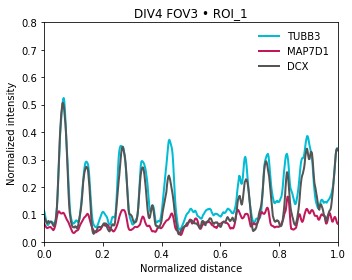

Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\DIV4_FOV3_ROI_2_intensity_norm_soma_max_smooth.png
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\DIV4_FOV3_ROI_2_intensity_norm_soma_max_smooth.svg


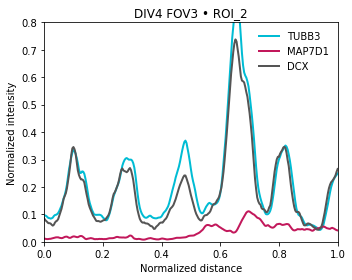

Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\DIV4_FOV3_ROI_3_intensity_norm_soma_max_smooth.png
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles\DIV4_FOV3_ROI_3_intensity_norm_soma_max_smooth.svg


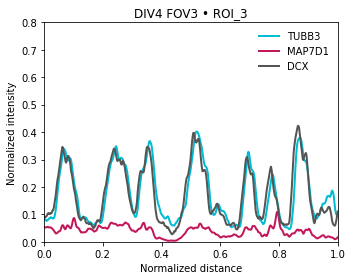

In [20]:
#Select profiles to plot from available DIVs (div) and FOVs (fov), and select number of ROIs to plot and save (n_rois)

plot_lineprofiles_by_div_fov(
    processed_df,
    div="DIV4",
    fov="FOV3",
    n_rois=3
)

## Step 5: Calculate and plot Pearson Coefficient per DIV ##

Comparisons are calculated between DCX, MAP7D1, MAP2, or EML4 and TUBB3 based on intensity peaks. 

In [25]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# --------------------------------------------------------
# Pearson correlations per matched ROI
# Pairwise: calculates whichever channel pairs are available
# --------------------------------------------------------

df = processed_df.copy()

print("Using dataframe: processed_df")
print("Columns:", df.columns.tolist())

common_x = np.linspace(0, 1, 200)

pairs = [
    ("TUBB3", "DCX"),
    ("TUBB3", "MAP7D1"),
]

# --------------------------------------------------------
# Automatically identify ROI/grouping columns
# --------------------------------------------------------

possible_roi_cols = [
    "roi_id", "ROI", "roi", "roi_name",
    "Name", "source_file", "file", "filename"
]

roi_col = None
for col in possible_roi_cols:
    if col in df.columns:
        roi_col = col
        break

if roi_col is None:
    raise KeyError(
        "Could not find an ROI column. Available columns are:\n"
        + str(df.columns.tolist())
    )

group_cols = []

for col in ["DIV", "FOV"]:
    if col in df.columns:
        group_cols.append(col)

group_cols.append(roi_col)

print(f"Grouping by: {group_cols}")

# --------------------------------------------------------
# Calculate Pearson correlations
# --------------------------------------------------------

corr_records = []
skipped_records = []

for group_key, roi_df in df.groupby(group_cols):

    if not isinstance(group_key, tuple):
        group_key = (group_key,)

    group_info = dict(zip(group_cols, group_key))

    roi_profiles = {}

    available_channels = sorted(roi_df["channel"].dropna().unique())

    for channel in available_channels:

        g = roi_df[
            roi_df["channel"] == channel
        ].sort_values("distance_um")

        if g.empty:
            continue

        x = g["distance_um"].to_numpy()
        y = g["intensity_norm_soma_max"].to_numpy()

        if len(x) < 2 or np.nanmax(x) == np.nanmin(x):
            continue

        x_norm = (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))
        y_interp = np.interp(common_x, x_norm, y)

        roi_profiles[channel] = y_interp

    for ch1, ch2 in pairs:

        if ch1 not in roi_profiles or ch2 not in roi_profiles:
            skipped_records.append({
                **group_info,
                "comparison": f"{ch1} vs {ch2}",
                "reason": "missing one or both channels"
            })
            continue

        r, p = pearsonr(
            roi_profiles[ch1],
            roi_profiles[ch2]
        )

        corr_records.append({
            **group_info,
            "comparison": f"{ch1} vs {ch2}",
            "channel_1": ch1,
            "channel_2": ch2,
            "pearson_r": r,
            "p_value": p
        })

pearson_df = pd.DataFrame(corr_records)
pearson_skipped = pd.DataFrame(skipped_records)

# --------------------------------------------------------
# Summary statistics
# --------------------------------------------------------

summary_group_cols = []

if "DIV" in pearson_df.columns:
    summary_group_cols.append("DIV")

summary_group_cols.append("comparison")

pearson_summary = (
    pearson_df
    .groupby(summary_group_cols, as_index=False)
    .agg(
        n_rois=(roi_col, "nunique"),
        mean_r=("pearson_r", "mean"),
        median_r=("pearson_r", "median"),
        sd_r=("pearson_r", "std"),
        sem_r=("pearson_r", lambda x: x.std() / np.sqrt(x.count()))
    )
)

# --------------------------------------------------------
# Save tables
# --------------------------------------------------------

pearson_df.to_csv(
    LINE_OUT_DIR / "Pearson_perROI_pairwise_available.csv",
    index=False
)

pearson_summary.to_csv(
    LINE_OUT_DIR / "Pearson_summary_pairwise_available.csv",
    index=False
)

pearson_skipped.to_csv(
    LINE_OUT_DIR / "Pearson_skipped_missing_pairs.csv",
    index=False
)

print(f"Pearson tables saved to:\n{LINE_OUT_DIR}")

display(pearson_df)
display(pearson_summary)
display(pearson_skipped)

Using dataframe: processed_df
Columns: ['DIV', 'FOV', 'species', 'channel', 'roi_id', 'source_file', 'source_column', 'distance_um', 'distance_norm', 'intensity_raw', 'background_value', 'soma_max_value', 'intensity_bgsub', 'intensity_bgsub_smooth', 'intensity_norm_soma_max', 'intensity_norm_soma_max_smooth', 'intensity_profile_minmax']
Grouping by: ['DIV', 'FOV', 'roi_id']
Pearson tables saved to:
D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis\Processed_LineProfiles


,DIV,FOV,roi_id,comparison,channel_1,channel_2,pearson_r,p_value
0,DIV3,FOV2,ROI_1,TUBB3 vs DCX,TUBB3,DCX,0.937723,7.262975e-93
1,DIV3,FOV2,ROI_1,TUBB3 vs MAP7D1,TUBB3,MAP7D1,0.534666,3.497754e-16
2,DIV3,FOV2,ROI_10,TUBB3 vs DCX,TUBB3,DCX,0.934643,7.399310e-91
3,DIV3,FOV2,ROI_10,TUBB3 vs MAP7D1,TUBB3,MAP7D1,0.272199,9.649947e-05
4,DIV3,FOV2,ROI_11,TUBB3 vs DCX,TUBB3,DCX,0.993171,1.032771e-186
...,...,...,...,...,...,...,...,...
268,DIV5,FOV3,ROI_5,TUBB3 vs MAP7D1,TUBB3,MAP7D1,0.657697,3.714199e-26
269,DIV5,FOV3,ROI_6,TUBB3 vs MAP7D1,TUBB3,MAP7D1,0.840510,1.339692e-54
270,DIV5,FOV3,ROI_7,TUBB3 vs MAP7D1,TUBB3,MAP7D1,0.720183,2.858210e-33
271,DIV5,FOV3,ROI_8,TUBB3 vs MAP7D1,TUBB3,MAP7D1,0.764795,1.158579e-39


,DIV,comparison,n_rois,mean_r,median_r,sd_r,sem_r
0,DIV3,TUBB3 vs DCX,27,0.909612,0.937667,0.066353,0.010625
1,DIV3,TUBB3 vs MAP7D1,27,0.365599,0.414761,0.274152,0.043900
2,DIV4,TUBB3 vs DCX,30,0.881653,0.898693,0.089720,0.010724
3,DIV4,TUBB3 vs MAP7D1,30,0.532456,0.570500,0.195346,0.023348
4,DIV5,TUBB3 vs MAP7D1,22,0.505974,0.528537,0.232915,0.031406


,DIV,FOV,roi_id,comparison,reason
0,DIV5,FOV1,ROI_1,TUBB3 vs DCX,missing one or both channels
1,DIV5,FOV1,ROI_10,TUBB3 vs DCX,missing one or both channels
2,DIV5,FOV1,ROI_11,TUBB3 vs DCX,missing one or both channels
3,DIV5,FOV1,ROI_12,TUBB3 vs DCX,missing one or both channels
4,DIV5,FOV1,ROI_13,TUBB3 vs DCX,missing one or both channels
5,DIV5,FOV1,ROI_14,TUBB3 vs DCX,missing one or both channels
6,DIV5,FOV1,ROI_15,TUBB3 vs DCX,missing one or both channels
7,DIV5,FOV1,ROI_16,TUBB3 vs DCX,missing one or both channels
8,DIV5,FOV1,ROI_17,TUBB3 vs DCX,missing one or both channels
9,DIV5,FOV1,ROI_18,TUBB3 vs DCX,missing one or both channels


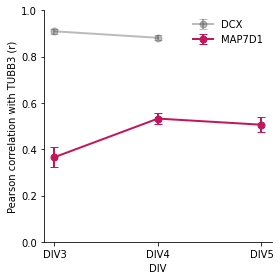

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# Clean comparison labels
# --------------------------------------------------------

plot_df = pearson_summary.copy()

plot_df["plot_label"] = plot_df["comparison"].replace({
    "TUBB3 vs DCX": "DCX",
    "DCX vs TUBB3": "DCX",
    "TUBB3 vs MAP7D1": "MAP7D1",
    "MAP7D1 vs TUBB3": "MAP7D1"
})

colors = {
    "DCX": "#555555",
    # "EML4": "#F48FB1"
    "MAP7D1": "#C2185B"
}

alphas = {
    "DCX": 0.4,
    "MAP7D1": 1.0
}

# --------------------------------------------------------
# Plot mean Pearson r ± SEM by DIV
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 4))

for label in ["DCX", "MAP7D1"]:

    df = (
        plot_df[plot_df["plot_label"] == label]
        .sort_values("DIV")
    )

    if df.empty:
        print(f"No data found for {label}")
        continue

    ax.errorbar(
        df["DIV"],
        df["mean_r"],
        yerr=df["sem_r"],
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=4,
        color=colors[label],
        alpha=alphas[label],
        label=label
    )

ax.set_xlabel("DIV")
ax.set_ylabel("Pearson correlation with TUBB3 (r)")

ax.set_xticks(sorted(plot_df["DIV"].unique()))
ax.set_ylim(0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out")

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    LINE_OUT_DIR / "Pearson_TUBB3_vs_DIV.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    LINE_OUT_DIR / "Pearson_TUBB3_vs_DIV.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()